### The basic model

In [237]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm

import holodeck as holo
from holodeck import sams
from holodeck import utils, plot
from holodeck.constants import MSOL, YR, PC

plt.style.use("/home/sam/work/sim.mplstyle")

holo.log.setLevel(holo.log.ERROR)

In [238]:
shape = 30
NUM_REALS = 100
NUM_LOUDEST = 0

gsmf = holo.sams.GSMF_Schechter()                    # Galaxy Stellar-Mass Function (GSMF)
gpf = holo.sams.GPF_Power_Law()                      # Galaxy Pair Fraction         (GPF)
gmt = holo.sams.GMT_Power_Law()                      # Galaxy Merger Time           (GMT)
mmbulge = holo.host_relations.MMBulge_MM2013()       # M-MBulge Relation            (MMB)
sam = holo.sams.Semi_Analytic_Model(gsmf=gsmf, gpf=gpf, gmt=gmt, mmbulge=mmbulge, shape=shape)

In [239]:
OBS_DUR = 10.0 * YR
NUM_FREQS = 10

fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
hard_gw = holo.hardening.Hard_GW()

lifetime = 1e9 * YR  ## <-- try changing this
gamma_inner = -1.0 ## <-- try changing this
hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
    fobs, sam, hard_ph, holo.cosmo
)

# ---------------------- #

hc_ss_gw, hc_gw = sam.gwb(fobs_edges, hard = hard_gw, realize=NUM_REALS, loudest=NUM_LOUDEST)

hc_ss, hc_true = sam.gwb(fobs_edges, hard = hard_ph, realize=NUM_REALS, loudest=NUM_LOUDEST)

edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges]
number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()


Effect of Hardening

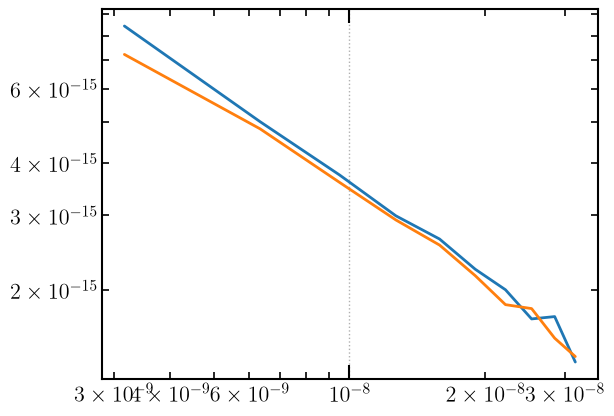

In [240]:
plt.loglog(fobs, np.average(hc_gw, 1));
plt.loglog(fobs, np.average(hc_true, 1));

### Checking sources properties 

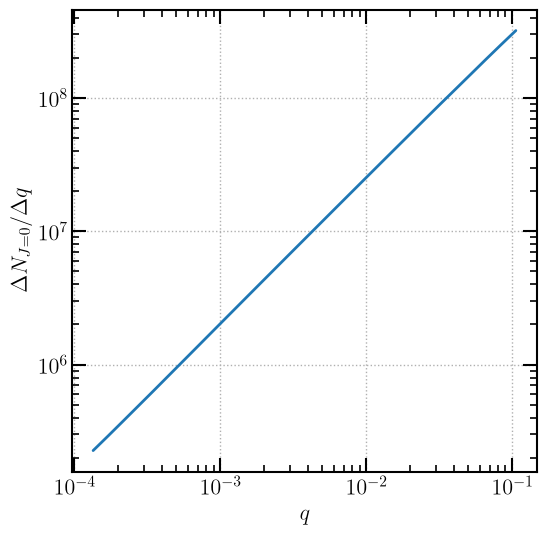

In [241]:
NJ = np.sum(number[:,:,:,0], (0,2))

fig, axs = plt.subplots(figsize=(6,6))
axs.loglog( (sam.mrat[1:] - sam.mrat[:-1])/2 , NJ)
axs.set_xlabel(r"$q$")
axs.set_ylabel(r"$\Delta N_{J=0}/\Delta q$")
fig.show()

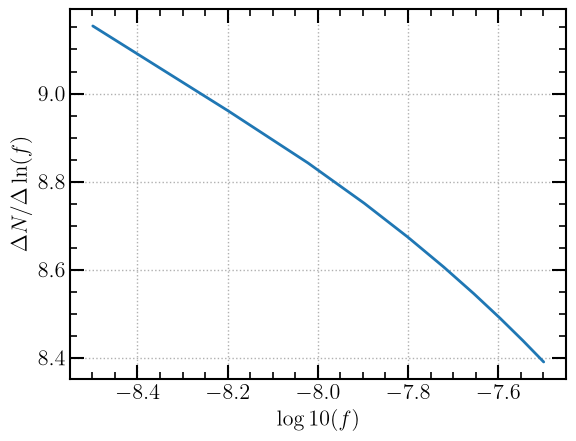

In [242]:
NJ = np.sum(number, (0,1,2))

plt.plot(np.log10(fobs), np.log10(NJ))
plt.xlabel(r'$\log10 (f)$');
plt.ylabel(r'$\Delta N/ \Delta \ln (f)$');

hc_bg_J = np.sum(hc_bg, 1)
f_avg_J_yr = fobs * YR
AJ = (hc_bg_J * (f_avg_J_yr)**(2/3)) / NJ

### Change of sGWB

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()


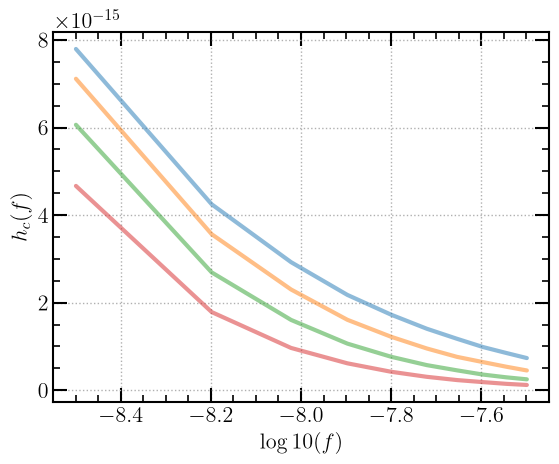

In [243]:
OBS_DUR = 10.0 * YR
NUM_FREQS = 10

for NUM_LOUDEST in [10, 100, int(1e3), int(1e4)]:
    OBS_DUR = 10.0 * YR
    NUM_FREQS = 10

    fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
    hard_gw = holo.hardening.Hard_GW()

    lifetime = 1e9 * YR  ## <-- try changing this
    gamma_inner = -1.0 ## <-- try changing this
    hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
    redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
        fobs, sam, hard_ph, holo.cosmo
    )

    # ---------------------- #

    hc_ss, hc_bg = sam.gwb(fobs_edges, hard = hard_gw, realize=NUM_REALS, loudest=NUM_LOUDEST)

    edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges]
    number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)

    plt.plot(np.log10(fobs), np.average(hc_bg,1), lw=3, alpha=0.5);

plt.xlabel(r'$\log10(f)$')
plt.ylabel(r'$h_c(f)$')
plt.show()

### Calc AJ

In [338]:
OBS_DUR = 10.0 * YR
NUM_FREQS = 30

fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
hard_gw = holo.hardening.Hard_GW()

lifetime = 1e9 * YR  ## <-- try changing this
gamma_inner = -1.0 ## <-- try changing this
hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
    fobs, sam, hard_ph, holo.cosmo
)

# ---------------------- #

hc_ss_gw, hc_gw = sam.gwb(fobs_edges, hard = hard_gw, realize=NUM_REALS, loudest=NUM_LOUDEST)

hc_ss, hc_true = sam.gwb(fobs_edges, hard = hard_ph, realize=NUM_REALS, loudest=NUM_LOUDEST)

edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges]
number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()


In [382]:
from astropy.cosmology import Planck15
from astropy import constants

cosmo = Planck15

def get_ampli_vec(M, mrat, z, f):
    c = constants.c.cgs.value
    g = constants.G.cgs.value
    d_l = cosmo.luminosity_distance(z).cgs.value  # shape (len(z),)

    # chirp mass, shape (M, mrat, 1, 1) so it broadcasts against z and f
    Mc = M[:,None,None,None] * (mrat[None,:,None,None] / (1+mrat[None,:,None,None])**2)**(3/5)

    d_l = d_l[None,None,:,None]        # (1,1,z,1)
    f   = np.asarray(f)[None,None,None,:]  # (1,1,1,freq)

    A = 2 * (g*Mc)**(5/3) / (d_l*c**4) * (np.pi*f)**(2/3)
    return A  # shape (M, mrat, z, freq)


mtot = (sam.mtot[1:] + sam.mtot[:-1])/2
mrat = (sam.mrat[1:] + sam.mrat[:-1])/2
redz = (sam.redz[1:] + sam.redz[:-1])/2

A_j = get_ampli_vec(mtot, mrat, redz, fobs)

print(A_j[np.argmin(abs(mtot - 1e9*constants.M_sun.cgs.value)), np.argmin(abs(mrat - 1)), np.argmin(abs(redz - .01)), np.argmin(abs(fobs - 3e-9))])
# np.log10(sam.mtot/constants.M_sun.cgs.value)[-5]


3.660471881882111e-16


In [349]:
print(np.sum(N_j, (0,1,2)))

[1.42384822e+09 9.12089741e+08 6.95430796e+08 5.63075271e+08
 4.71405432e+08 4.03482660e+08 3.50834220e+08 3.08717232e+08
 2.74243020e+08 2.45487701e+08 2.21098228e+08 2.00224915e+08
 1.82112881e+08 1.66315026e+08 1.52376940e+08 1.40061835e+08
 1.29065612e+08 1.19225181e+08 1.10388840e+08 1.02394534e+08
 9.51561365e+07 8.85911156e+07 8.25976521e+07 7.71160880e+07
 7.21064650e+07 6.75103163e+07 6.32770296e+07 5.93732297e+07
 5.57758182e+07 5.24539199e+07]


[1.00086217e+01 2.65922650e+01 6.34491641e+01 1.63590478e+02
 2.47539975e+02 4.80604961e+02 8.34463463e+02 1.25552947e+03
 1.73392292e+03 2.54673273e+03 3.58663613e+03 4.93510058e+03
 6.48728031e+03 8.13826520e+03 9.66529702e+03 1.10027855e+04
 1.27667575e+04 1.57094023e+04 1.91542039e+04 2.31180105e+04
 2.73727340e+04 3.24640080e+04 3.70030951e+04 4.32528327e+04
 5.03002152e+04 5.37873313e+04 6.17704858e+04 6.09277408e+04
 5.61214136e+04 6.35536749e+04]


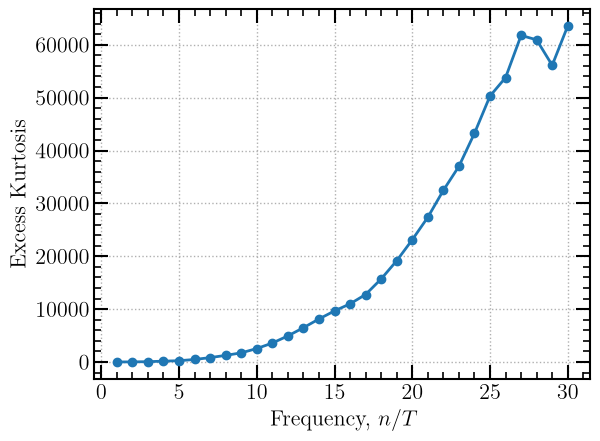

In [348]:
N_j = number

num = np.sum(N_j * A_j**4 / fobs**4, axis=(0,1,2))
den = np.sum(N_j * A_j**2 / fobs**2, axis=(0,1,2))
k_i = num / den**2

print(k_i)
plt.plot(fobs*OBS_DUR, k_i, '-o')
plt.xlabel(r"Frequency, $n/T$")
plt.ylabel(r"Excess Kurtosis")
plt.show()

## Ver 2

In [458]:
import numpy as np
import matplotlib.pyplot as plt

def get_coefs(A_j, n_real):
    N = len(A_j)
    omega = np.random.uniform(0, 2*np.pi/OBS_DUR, size=(n_real, N))
    f = omega/(2*np.pi)
    phi = omega*OBS_DUR
    a = np.sum((A_j/(4*np.pi*1j))[None,:] * np.exp(1j*phi), axis=1)
    return a

def moments_and_kurtosis(a):
    m2 = np.mean(np.abs(a)**2)
    m4 = np.mean(np.abs(a)**4)
    kappa = m4/m2**2 - 2
    return m2, m4, kappa

# def analytic_kappa(A_j):
#     num = np.sum(A_j**4/16)
#     den = np.sum(A_j**2/4)**2
#     return num/den - 2

/home/sam/work/learn/viper_school/gw-school-2026-materials/.venv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)


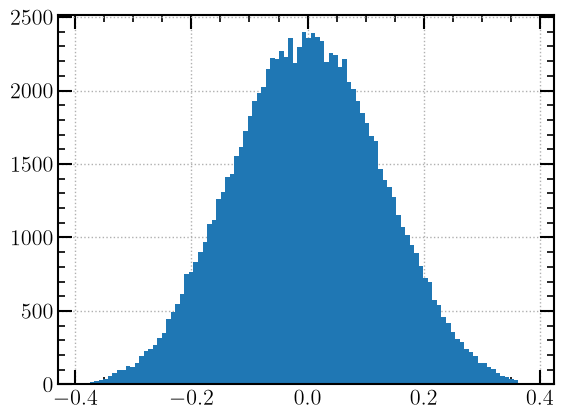

In [459]:
A_j = np.array([1.0])
A_j = np.ones(5)
a = get_coefs(A_j, n_real=int(10**5))
m2, m4, k = moments_and_kurtosis(a)
plt.hist(a, bins=100);

# print("N=1:", k, analytic_kappa(A_j))

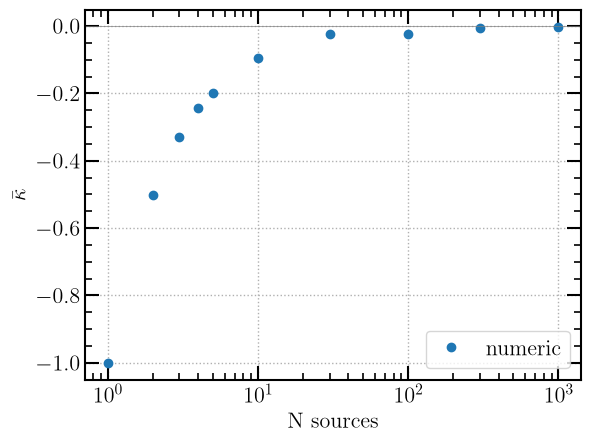

In [460]:
Ns = [1, 2, 3, 4, 5, 10, 30, 100, 300, 1000]
kappas_num, kappas_ana = [], []

for N in Ns:
    A_j = np.ones(N)
    a = get_coefs(A_j, n_real=int(10**5))
    _, _, k = moments_and_kurtosis(a)
    kappas_num.append(k)
    # kappas_ana.append(analytic_kappa(A_j))

plt.semilogx(Ns, kappas_num, 'o', label='numeric')
# plt.semilogx(Ns, kappas_ana, '--', label='analytic')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel("N sources"); 
plt.ylabel(r"$\bar\kappa$"); 
plt.legend();

### Estimating N90 (not working)

In [250]:
from tqdm.notebook import tqdm

def check_error(hc_ss, hc_bg, hc_true):
    #sum over sources - quadrature because it's a variance!
    hc_ss_source = np.sqrt(np.sum(hc_ss**2, axis=2)) 
    # print(hc_ss_source.shape)
    #average over realizations
    hc_ss_real = np.average(hc_ss_source, axis=1)
    hc_true_real = np.average(hc_true, axis=1)
    hc_bg_real = np.average(hc_bg, axis=1)

    #print difference
    total_err = (hc_true_real - np.sqrt(hc_ss_real**2+hc_bg_real**2))/hc_true_real
    ss_err = (hc_true_real - hc_ss_real)/hc_true_real

    return total_err, ss_err

# to loop over frequencies
def find_N90(fobs, sam, hc_true):
    N_90 = np.zeros(NUM_FREQS)
    err_90 = np.zeros(NUM_FREQS)
    for i in range(len(fobs)):
        print(f"Doing frequency {fobs[i]}")
        step= np.max([int(500/(i+1)), 1])
        #print(step)
        for NUM_LOUDEST in tqdm(range(1, int(1e5), step)):
            fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
            hc_ss, hc_bg = sam.gwb(fobs_edges, hard=hard_ph ,realize=NUM_REALS, loudest=NUM_LOUDEST)
            ss_err = check_error(hc_ss, hc_bg, hc_true)[1]

            # print(f"{ss_err[i]:.1e}")
            if (abs(ss_err[i]) <= 0.1): 
                N_90[i] = NUM_LOUDEST
                err_90[i] = ss_err[i]
                print(N_90[i])
                break

    return N_90, err_90

In [251]:
import itertools
import numpy as np
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib

NUM_FREQS = 10
NUM_REALS = 100
OBS_DUR = 10.0 * YR


fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
_, hc_true = sam.gwb(fobs_edges, hard=hard_ph, realize=NUM_REALS, loudest=NUM_LOUDEST)

passed redz check at the beginning of ss_gws_redz()


In [ ]:
# N_90, err_90 = find_N90(fobs, sam, hc_true)

Doing frequency 3.168808781402895e-09


  0%|          | 0/200 [00:00<?, ?it/s]

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz 

  0%|          | 0/400 [00:00<?, ?it/s]

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz 

KeyboardInterrupt: 

In [ ]:
np.save('N90.npy', np.vstack([N_90, err_90]))

In [ ]:
N_90, err_90 = np.load('N90.npy')

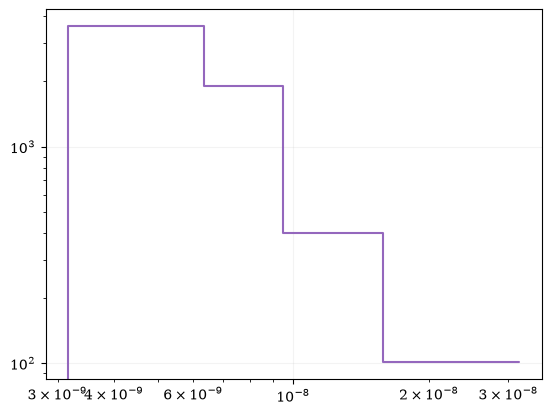

In [ ]:
plt.step(fobs, N_90, c='C4')
plt.xscale('log')
plt.yscale('log')